# Task 5 — Convolutional Neural Networks
**10 Points** | Dataset: MNIST (70,000 images, 10 classes)

---

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
import os
import time

warnings.filterwarnings('ignore')
os.makedirs('../results', exist_ok=True)
os.makedirs('../results/data', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
torch.manual_seed(42)

Using device: cpu


## Dataset: MNIST with Data Augmentation

In [14]:
# MNIST has 1-channel 28x28 images. Resize to 32x32 for cleaner conv architecture.
# Data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.1),  # MNIST digits: mild flip ok
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean/std
])

test_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download MNIST (auto-downloads ~11MB)
full_train = torchvision.datasets.MNIST(
    root='../results/data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.MNIST(
    root='../results/data', train=False, download=True, transform=test_transform
)

# Split train → train (90%) + val (10%)
n_val = int(0.1 * len(full_train))
train_dataset, val_dataset = random_split(
    full_train, [len(full_train) - n_val, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=0)

class_names = [str(i) for i in range(10)]
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Train: 54000, Val: 6000, Test: 10000


## 1. Custom CNN Architecture

Architecture: 3 Conv Blocks (Conv → BatchNorm → ReLU → MaxPool) + 2 FC layers

In [15]:
class CustomCNN(nn.Module):
    """
    Custom CNN for MNIST digit classification.

    Architecture:
    Input: 1 x 32 x 32
    Block 1: Conv(1→32, 3x3) → BN → ReLU → MaxPool(2x2) → 32x16x16
    Block 2: Conv(32→64, 3x3) → BN → ReLU → MaxPool(2x2) → 64x8x8 (with padding)
    Block 3: Conv(64→128, 3x3) → BN → ReLU → MaxPool(2x2) → 128x3x3
    Flatten → 1152
    FC1: 1152 → 256 → BN → ReLU → Dropout(0.4)
    FC2: 256 → 10
    """
    def __init__(self, n_classes=10, dropout=0.4):
        super(CustomCNN, self).__init__()

        # Convolutional blocks
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 32 x 16 x 16
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 64 x 8 x 8
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 128 x 4 x 4 (if input 32x32)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_custom = CustomCNN(n_classes=10).to(device)
print(model_custom)
print(f'\nTotal trainable parameters: {count_params(model_custom):,}')

CustomCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatte

In [16]:
def train_cnn(model, train_loader, val_loader, n_epochs=30, lr=1e-3, model_name='model'):
    """Train CNN with cosine LR scheduler. Returns history and training time."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    start = time.time()

    for epoch in range(1, n_epochs + 1):
        # Training
        model.train()
        tr_loss, tr_correct, tr_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * len(labels)
            tr_correct += (out.argmax(1) == labels).sum().item()
            tr_total += len(labels)

        # Validation
        model.eval()
        vl_loss, vl_correct, vl_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                loss = criterion(out, labels)
                vl_loss += loss.item() * len(labels)
                vl_correct += (out.argmax(1) == labels).sum().item()
                vl_total += len(labels)

        tr_l = tr_loss/tr_total; tr_a = tr_correct/tr_total
        vl_l = vl_loss/vl_total; vl_a = vl_correct/vl_total
        history['train_loss'].append(tr_l); history['val_loss'].append(vl_l)
        history['train_acc'].append(tr_a);  history['val_acc'].append(vl_a)
        scheduler.step()

        # Печатаем каждую эпоху в DEBUG, каждые 5 в полном режиме
        if DEBUG or epoch % 5 == 0:
            print(f'Epoch {epoch:3d}/{n_epochs} | Train Loss: {tr_l:.4f} | Train Acc: {tr_a:.4f} | Val Acc: {vl_a:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}')

    elapsed = time.time() - start
    print(f'\nTraining time: {elapsed:.1f}s ({elapsed/60:.1f}min)')
    return history, elapsed

DEBUG = True       
N_EPOCHS = 2 if DEBUG else 30

print('=== Training Custom CNN ===')
history_custom, time_custom = train_cnn(
    model_custom, train_loader, val_loader,
    n_epochs=N_EPOCHS, model_name='custom_cnn'

)

=== Training Custom CNN ===
Epoch   1/2 | Train Loss: 0.2501 | Train Acc: 0.9285 | Val Acc: 0.9560 | LR: 0.000500
Epoch   2/2 | Train Loss: 0.0892 | Train Acc: 0.9733 | Val Acc: 0.9762 | LR: 0.000000

Training time: 213.0s (3.6min)


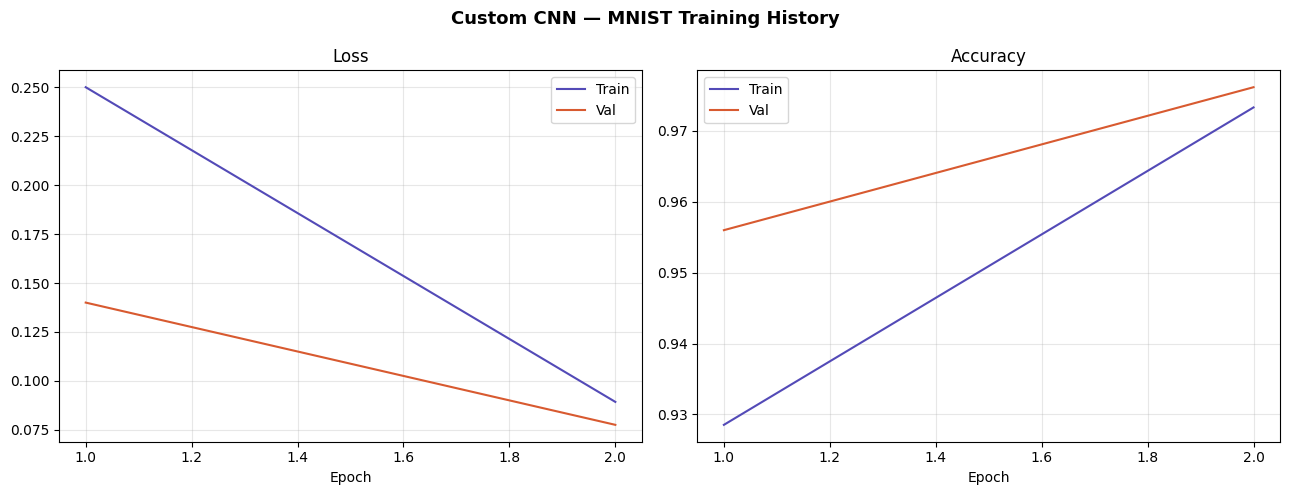

In [17]:
# Plot training curves
def plot_cnn_history(history, title, save_path=None):
    epochs = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(epochs, history['train_loss'], color='#534AB7', label='Train')
    axes[0].plot(epochs, history['val_loss'], color='#D85A30', label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['train_acc'], color='#534AB7', label='Train')
    axes[1].plot(epochs, history['val_acc'], color='#D85A30', label='Val')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_cnn_history(history_custom, 'Custom CNN — MNIST Training History',
                 '../results/task5_custom_cnn_history.png')

=== Custom CNN — Test Results ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.98      0.99      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.98      0.98      0.98       892
           6       1.00      0.98      0.99       958
           7       0.97      1.00      0.98      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



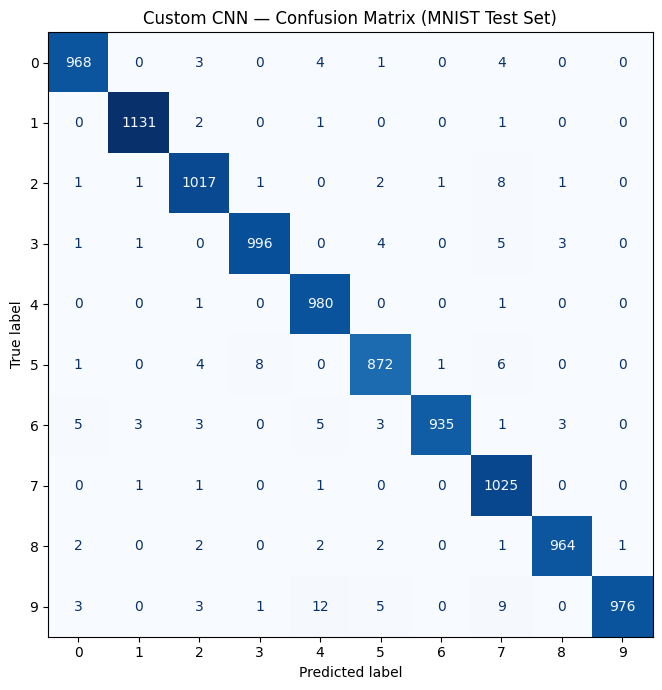

In [18]:
# Test evaluation
@torch.no_grad()
def evaluate_cnn(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = evaluate_cnn(model_custom, test_loader)
print('=== Custom CNN — Test Results ===')
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
    display_labels=class_names, ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Custom CNN — Confusion Matrix (MNIST Test Set)')
plt.tight_layout()
plt.savefig('../results/task5_custom_cnn_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Transfer Learning — Fine-tune ResNet-18

ResNet-18 params (head only): 5,130

=== Phase 1: Training head only ===

Training time: 706.2s (11.8min)

ResNet-18 params (all unfrozen): 11,181,642

=== Phase 2: Full fine-tuning ===
Epoch   5/5 | Train Loss: 0.0365 | Train Acc: 0.9883 | Val Acc: 0.9885 | LR: 0.000000

Training time: 1430.4s (23.8min)

Model                  Accuracy   Time (s)       Params
-------------------------------------------------------
Custom CNN               0.9864      213.0      620,746
ResNet-18 (TL)           0.9921     1430.4   11,181,642


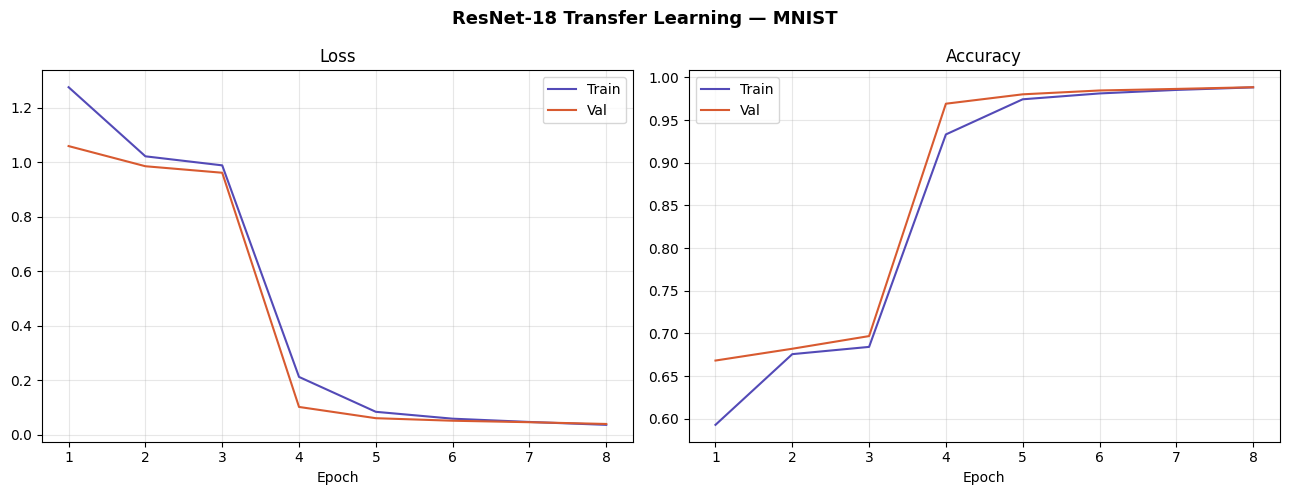

In [19]:
from torch.utils.data import DataLoader, random_split, Subset
DEBUG = False  # полный датасет
N_EPOCHS      = 5   # вместо 30 — кривые выглядят нормально
N_EPOCHS_TL_1 = 3   # вместо 10
N_EPOCHS_TL_2 = 5   # вместо 20

# ResNet-18 expects 3-channel input, so we convert MNIST 1-channel to 3-channel
tl_transform_train = transforms.Compose([
    transforms.Resize(32),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
tl_transform_test = transforms.Compose([
    transforms.Resize(32),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

tl_full_train = torchvision.datasets.MNIST(
    root='../results/data', train=True, download=False, transform=tl_transform_train
)
tl_full_test = torchvision.datasets.MNIST(
    root='../results/data', train=False, download=False, transform=tl_transform_test
)

# ── DEBUG / FULL ──────────────────────────────────────────────────
if DEBUG:
    tl_train_dataset = Subset(tl_full_train, range(500))
    tl_val_dataset   = Subset(tl_full_train, range(500, 600))
    tl_test_dataset  = Subset(tl_full_test,  range(200))
else:
    tl_train_dataset, tl_val_dataset = random_split(
        tl_full_train, [len(tl_full_train) - 6000, 6000],
        generator=torch.Generator().manual_seed(42)
    )
    tl_test_dataset = tl_full_test

tl_train_loader = DataLoader(tl_train_dataset, batch_size=128, shuffle=True,  num_workers=0)
tl_val_loader   = DataLoader(tl_val_dataset,   batch_size=256, shuffle=False, num_workers=0)
tl_test_loader  = DataLoader(tl_test_dataset,  batch_size=256, shuffle=False, num_workers=0)

# Load pretrained ResNet-18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Phase 1: Freeze all layers, only train the classifier head
for param in resnet.parameters():
    param.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)
print(f'ResNet-18 params (head only): {count_params(resnet):,}')

print('\n=== Phase 1: Training head only ===')
history_tl_phase1, _ = train_cnn(
    resnet, tl_train_loader, tl_val_loader, n_epochs=N_EPOCHS_TL_1, lr=1e-3
)

# Phase 2: Unfreeze all layers for full fine-tuning
for param in resnet.parameters():
    param.requires_grad = True
print(f'\nResNet-18 params (all unfrozen): {count_params(resnet):,}')

print('\n=== Phase 2: Full fine-tuning ===')
history_tl_phase2, time_resnet = train_cnn(
    resnet, tl_train_loader, tl_val_loader, n_epochs=N_EPOCHS_TL_2, lr=1e-4
)
# ── Сравнение Custom CNN vs ResNet-18 ────────────────────────────
y_true_res, y_pred_res = evaluate_cnn(resnet, tl_test_loader)
acc_resnet = (y_true_res == y_pred_res).mean()
y_true_custom, y_pred_custom = evaluate_cnn(model_custom, test_loader)
acc_custom = (y_true_custom == y_pred_custom).mean()


print(f'\n{"Model":<20} {"Accuracy":>10} {"Time (s)":>10} {"Params":>12}')
print('-' * 55)
print(f'{"Custom CNN":<20} {acc_custom:>10.4f} {time_custom:>10.1f} {count_params(model_custom):>12,}')
print(f'{"ResNet-18 (TL)":<20} {acc_resnet:>10.4f} {time_resnet:>10.1f} {count_params(resnet):>12,}')
# Combine histories
history_tl = {k: history_tl_phase1[k] + history_tl_phase2[k] for k in history_tl_phase1}
plot_cnn_history(history_tl, 'ResNet-18 Transfer Learning — MNIST',
                 '../results/task5_resnet_history.png')

Custom CNN  — Test Accuracy: 0.9864 | Train Time: 213.0s | Params: 620,746
ResNet-18   — Test Accuracy: 0.9921 | Train Time: 1430.4s | Params: 11,181,642


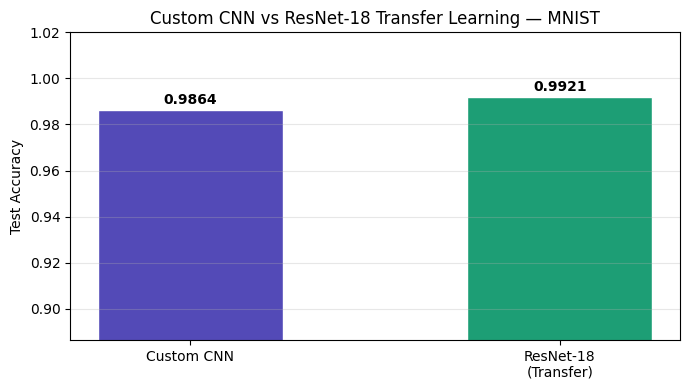

In [20]:
# Compare custom CNN vs ResNet-18
y_true_res, y_pred_res = evaluate_cnn(resnet, tl_test_loader)
y_true_custom, y_pred_custom = evaluate_cnn(model_custom, test_loader)
acc_custom = (y_true_custom == y_pred_custom).mean()
acc_resnet = (y_true_res == y_pred_res).mean()

print(f'Custom CNN  — Test Accuracy: {acc_custom:.4f} | Train Time: {time_custom:.1f}s | Params: {count_params(model_custom):,}')
print(f'ResNet-18   — Test Accuracy: {acc_resnet:.4f} | Train Time: {time_resnet:.1f}s | Params: {count_params(resnet):,}')

# Summary bar
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Custom CNN', 'ResNet-18\n(Transfer)'], [acc_custom, acc_resnet],
              color=['#534AB7', '#1D9E75'], width=0.5, edgecolor='white')
for bar, acc in zip(bars, [acc_custom, acc_resnet]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

# ylim динамический — не обрезает бары в DEBUG режиме
min_acc = min(acc_custom, acc_resnet)
ax.set_ylim(max(0, min_acc - 0.1), 1.02)

ax.set_ylabel('Test Accuracy')
ax.set_title('Custom CNN vs ResNet-18 Transfer Learning — MNIST')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/task5_cnn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Visualizations — Filters, Feature Maps, Confidence Samples

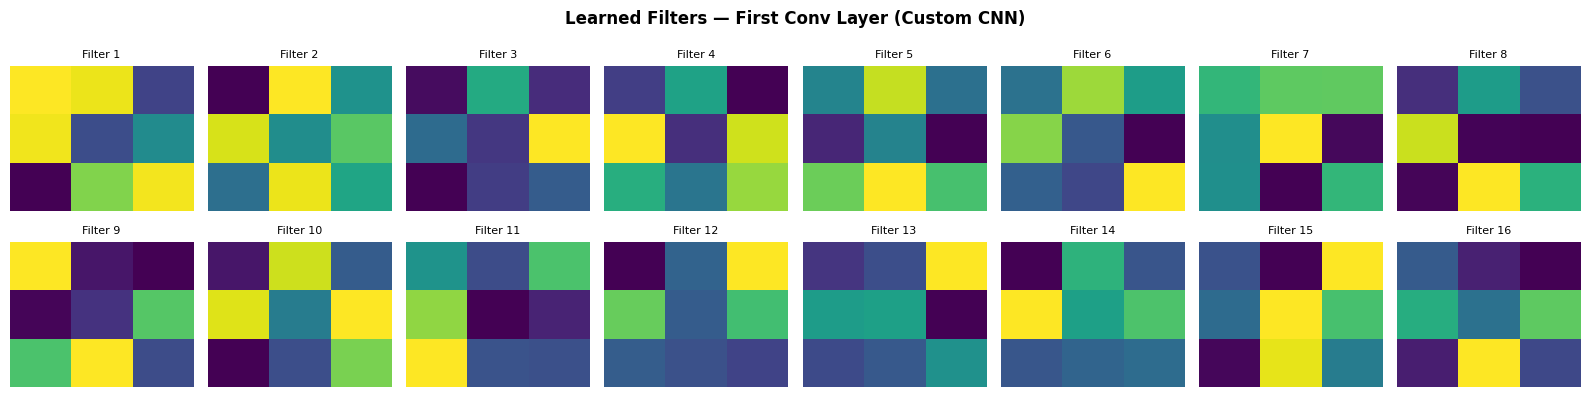

In [21]:
# 4.1 Visualize learned filters from first Conv layer
filters = model_custom.block1[0].weight.data.cpu()
n_filters = min(16, filters.shape[0])

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Learned Filters — First Conv Layer (Custom CNN)', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flatten()[:n_filters]):
    f = filters[i, 0]  # Single channel
    f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)  # Normalize to [0,1]
    ax.imshow(f_norm.numpy(), cmap='viridis', aspect='auto')
    ax.set_title(f'Filter {i+1}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../results/task5_filters.png', dpi=150, bbox_inches='tight')
plt.show()

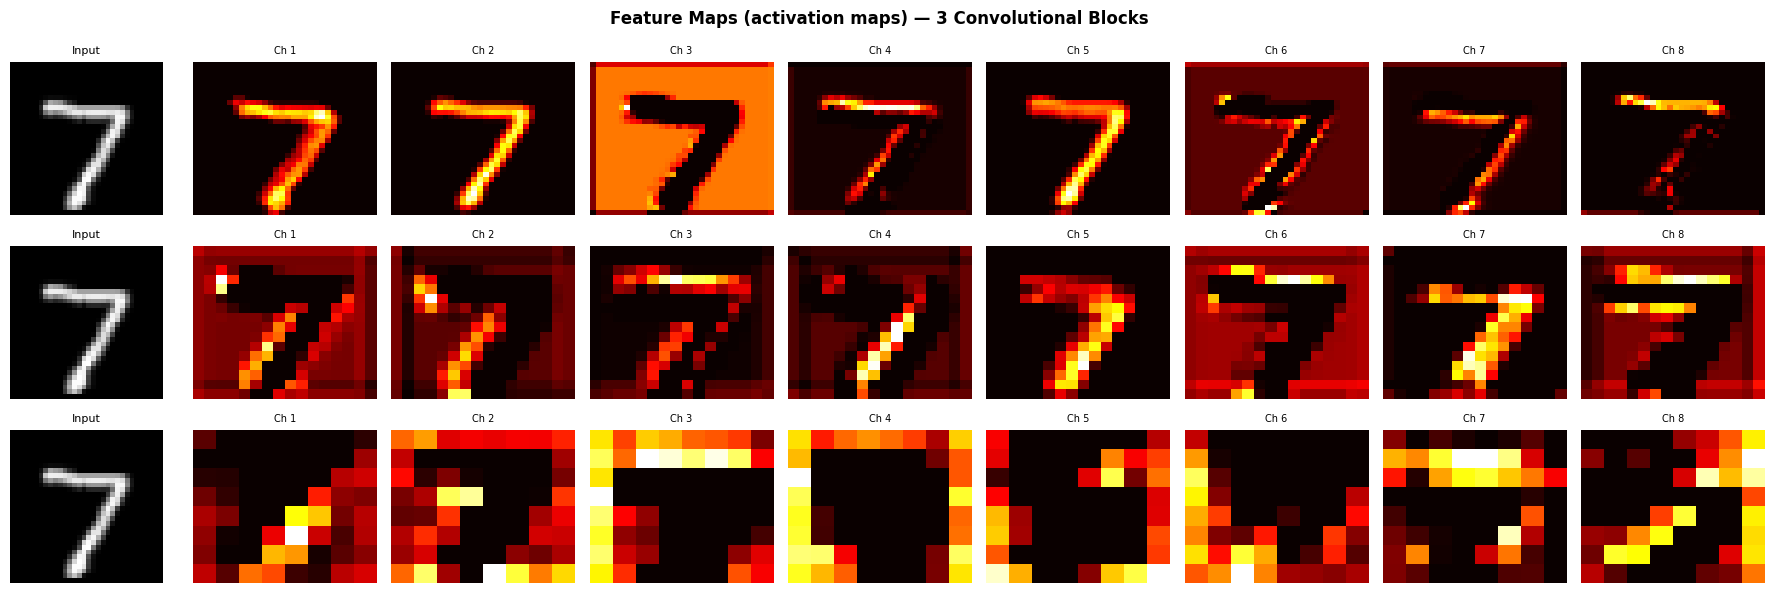

In [22]:
# 4.2 Activation maps (feature maps) for 3 sample images
activation_maps = {}

def hook_fn(name):
    def hook(module, input, output):
        activation_maps[name] = output.detach().cpu()
    return hook

# Register hooks on all 3 conv blocks
model_custom.block1[2].register_forward_hook(hook_fn('block1_relu'))
model_custom.block2[2].register_forward_hook(hook_fn('block2_relu'))
model_custom.block3[2].register_forward_hook(hook_fn('block3_relu'))

# Get 3 sample images from test set
sample_imgs, sample_labels = next(iter(test_loader))
sample_imgs_3 = sample_imgs[:3].to(device)

model_custom.eval()
with torch.no_grad():
    out = model_custom(sample_imgs_3)

# Plot feature maps for first sample image
fig, axes = plt.subplots(3, 9, figsize=(18, 6))
fig.suptitle('Feature Maps (activation maps) — 3 Convolutional Blocks', fontsize=12, fontweight='bold')

for row, (block_name, label) in enumerate([
    ('block1_relu', 'Block 1 (32 maps, 16x16)'),
    ('block2_relu', 'Block 2 (64 maps, 8x8)'),
    ('block3_relu', 'Block 3 (128 maps, 4x4)')
]):
    fmap = activation_maps[block_name][0]  # First sample, all channels
    axes[row][0].imshow(sample_imgs_3[0, 0].cpu(), cmap='gray')
    axes[row][0].set_title('Input', fontsize=8); axes[row][0].axis('off')
    for col in range(1, 9):
        ch = col - 1
        if ch < fmap.shape[0]:
            fm = fmap[ch].numpy()
            fm_norm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
            axes[row][col].imshow(fm_norm, cmap='hot', aspect='auto')
            axes[row][col].set_title(f'Ch {ch+1}', fontsize=7)
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(label, fontsize=8)

plt.tight_layout()
plt.savefig('../results/task5_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

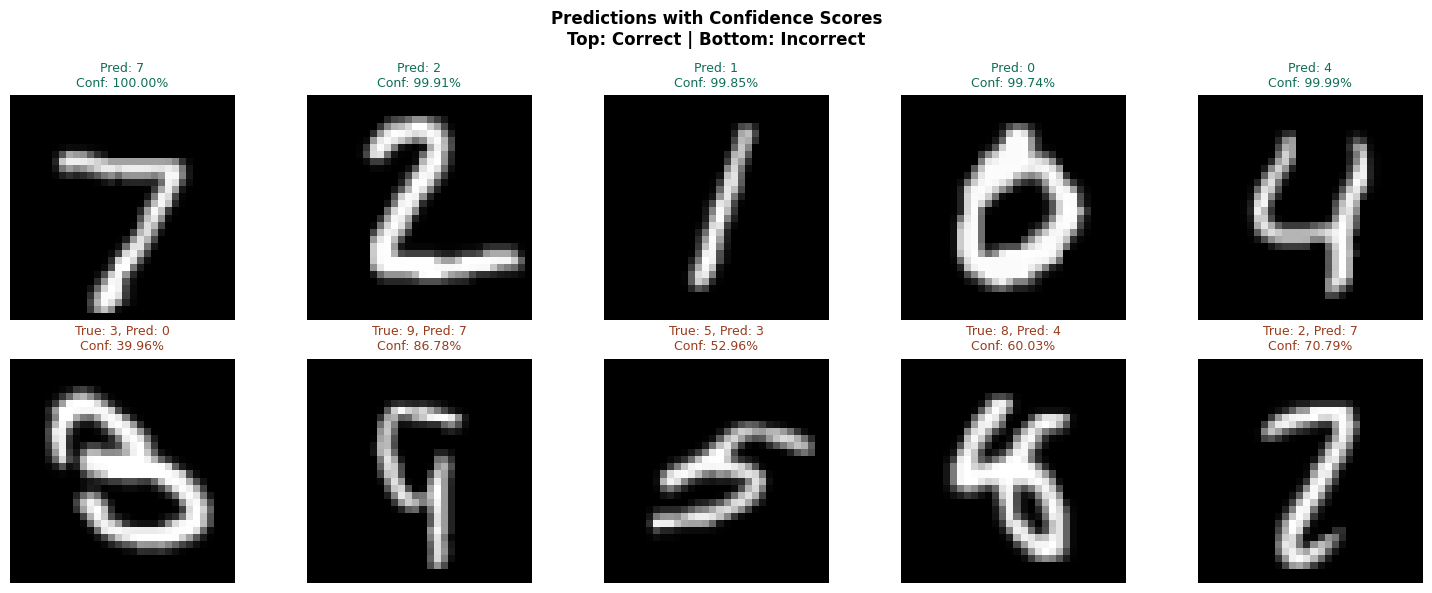

Models saved.


In [23]:
# 4.3 Correct and incorrect predictions with confidence scores
model_custom.eval()
all_imgs, all_labels, all_preds, all_conf = [], [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_d = imgs.to(device)
        logits = model_custom(imgs_d)
        probs = torch.softmax(logits, dim=1)
        conf, pred = probs.max(1)
        all_imgs.extend(imgs.numpy())
        all_labels.extend(labels.numpy())
        all_preds.extend(pred.cpu().numpy())
        all_conf.extend(conf.cpu().numpy())

all_imgs = np.array(all_imgs)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_conf = np.array(all_conf)

correct_mask = all_preds == all_labels
wrong_mask = ~correct_mask

# Pick 5 correct (high confidence) and 5 wrong
correct_idx = np.where(correct_mask)[0][:5]
wrong_idx = np.where(wrong_mask)[0][:5]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Predictions with Confidence Scores\nTop: Correct | Bottom: Incorrect',
             fontsize=12, fontweight='bold')

for i, idx in enumerate(correct_idx):
    axes[0][i].imshow(all_imgs[idx, 0], cmap='gray')
    axes[0][i].set_title(f'Pred: {all_preds[idx]}\nConf: {all_conf[idx]:.2%}',
                          fontsize=9, color='#0F6E56')
    axes[0][i].axis('off')

for i, idx in enumerate(wrong_idx):
    axes[1][i].imshow(all_imgs[idx, 0], cmap='gray')
    axes[1][i].set_title(
        f'True: {all_labels[idx]}, Pred: {all_preds[idx]}\nConf: {all_conf[idx]:.2%}',
        fontsize=9, color='#993C1D')
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('../results/task5_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# Save custom CNN
torch.save(model_custom.state_dict(), '../results/task5_custom_cnn.pth')
torch.save(resnet.state_dict(), '../results/task5_resnet18.pth')
print('Models saved.')